## Importing libraries 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

import my_config  

from fredapi import Fred



In [2]:
fred_key = my_config.FRED_API_KEY
print(f"Key Loaded Succesfully")

Key Loaded Succesfully


In [3]:
fred = Fred(api_key=fred_key)
fred

In [4]:
## previewing of all tables that will be used   

In [5]:
## Searching for specific data

fred_search = fred.search("CPIAUCSL") ## Consumer price index
fred_search.head(4)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
CPIAUCSL,CPIAUCSL,2026-06-28,2026-06-28,Consumer Price Index for All Urban Consumers: ...,1947-01-01,2026-05-01,Monthly,M,Index 1982-1984=100,Index 1982-1984=100,Seasonally Adjusted,SA,2026-06-10 08:20:52-05:00,97,The Consumer Price Index for All Urban Consume...
RRSFS,RRSFS,2026-06-28,2026-06-28,Advance Real Retail and Food Services Sales,1992-01-01,2026-05-01,Monthly,M,Millions of 1982-84 CPI Adjusted Dollars,Mil. of 1982-84 CPI Adjusted $,Seasonally Adjusted,SA,2026-06-17 07:42:38-05:00,60,The data in this series are calculated using t...
AMBSLREAL,AMBSLREAL,2026-06-28,2026-06-28,Real St. Louis Adjusted Monetary Base (DISCONT...,1947-01-01,2019-11-01,Monthly,M,Billions of 1982-84 Dollars,Bil. of 1982-84 $,Seasonally Adjusted,SA,2020-03-11 13:03:01-05:00,4,This series deflates St. Louis Adjusted Moneta...
MZMREAL,MZMREAL,2026-06-28,2026-06-28,Real MZM Money Stock (DISCONTINUED),1959-01-01,2021-01-01,Monthly,M,Billions of 1982-84 Dollars,Bil. of 1982-84 $,Seasonally Adjusted,SA,2026-03-24 12:14:46-05:00,2,This series has been discontinued and will no ...


In [6]:
fred_search = fred.search("CPILFESL") ## Core inflation
fred_search.head(4)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
CPILFESL,CPILFESL,2026-06-28,2026-06-28,Consumer Price Index for All Urban Consumers: ...,1957-01-01,2026-05-01,Monthly,M,Index 1982-1984=100,Index 1982-1984=100,Seasonally Adjusted,SA,2026-06-10 08:20:44-05:00,84,"The ""Consumer Price Index for All Urban Consum..."
CPIAUCSL,CPIAUCSL,2026-06-28,2026-06-28,Consumer Price Index for All Urban Consumers: ...,1947-01-01,2026-05-01,Monthly,M,Index 1982-1984=100,Index 1982-1984=100,Seasonally Adjusted,SA,2026-06-10 08:20:52-05:00,97,The Consumer Price Index for All Urban Consume...


In [7]:
fred_search = fred.search("FEDFUNDS") ## policy rate
fred_search.shape

(1, 15)

In [8]:
fred_search = fred.search("DGS10") ## long term rate
fred_search.shape

(3, 15)

## Pulling RAW data

In [9]:
cpi = fred.get_series('CPIAUCSL')
cpi

1947-01-01     21.480
1947-02-01     21.620
1947-03-01     22.000
1947-04-01     22.000
1947-05-01     21.950
               ...   
2026-01-01    326.588
2026-02-01    327.460
2026-03-01    330.293
2026-04-01    332.407
2026-05-01    333.979
Length: 953, dtype: float64

In [10]:
core_cpi = fred.get_series('CPILFESL')
core_cpi.head(2)

1957-01-01    28.5
1957-02-01    28.6
dtype: float64

In [11]:
fed_funds = fred.get_series('FEDFUNDS')
fed_funds.tail()

2026-01-01    3.64
2026-02-01    3.64
2026-03-01    3.64
2026-04-01    3.64
2026-05-01    3.63
dtype: float64

In [12]:
treasury = fred.get_series('DGS10')
treasury.head(2)

1962-01-02    4.06
1962-01-03    4.03
dtype: float64

In [13]:
## Combining all the data tables 

In [14]:
df  = pd.concat([cpi,core_cpi,fed_funds,treasury], axis=1)

df.columns = [
    "headline_cpi",
    "core_cpi",
    "fed_funds_rate",
    "treasury_10y_rate"
]

## Cleaning data

In [15]:
print(cpi.head())
print(core_cpi.head())
print(fed_funds.head())
print(treasury.head())

1947-01-01    21.48
1947-02-01    21.62
1947-03-01    22.00
1947-04-01    22.00
1947-05-01    21.95
dtype: float64
1957-01-01    28.5
1957-02-01    28.6
1957-03-01    28.7
1957-04-01    28.8
1957-05-01    28.8
dtype: float64
1954-07-01    0.80
1954-08-01    1.22
1954-09-01    1.07
1954-10-01    0.85
1954-11-01    0.83
dtype: float64
1962-01-02    4.06
1962-01-03    4.03
1962-01-04    3.99
1962-01-05    4.02
1962-01-08    4.03
dtype: float64


In [16]:
df.info

<bound method DataFrame.info of             headline_cpi  core_cpi  fed_funds_rate  treasury_10y_rate
1947-01-01         21.48       NaN             NaN                NaN
1947-02-01         21.62       NaN             NaN                NaN
1947-03-01         22.00       NaN             NaN                NaN
1947-04-01         22.00       NaN             NaN                NaN
1947-05-01         21.95       NaN             NaN                NaN
...                  ...       ...             ...                ...
2026-06-19           NaN       NaN             NaN                NaN
2026-06-22           NaN       NaN             NaN               4.51
2026-06-23           NaN       NaN             NaN               4.50
2026-06-24           NaN       NaN             NaN               4.41
2026-06-25           NaN       NaN             NaN               4.40

[17225 rows x 4 columns]>

In [17]:
## Preveiwing data 

df.head(5)

,headline_cpi,core_cpi,fed_funds_rate,treasury_10y_rate
1947-01-01,21.48,NaN,NaN,NaN
1947-02-01,21.62,NaN,NaN,NaN
1947-03-01,22.00,NaN,NaN,NaN
1947-04-01,22.00,NaN,NaN,NaN
1947-05-01,21.95,NaN,NaN,NaN


In [18]:
df.tail(5)

,headline_cpi,core_cpi,fed_funds_rate,treasury_10y_rate
2026-06-19,NaN,NaN,NaN,NaN
2026-06-22,NaN,NaN,NaN,4.51
2026-06-23,NaN,NaN,NaN,4.50
2026-06-24,NaN,NaN,NaN,4.41
2026-06-25,NaN,NaN,NaN,4.40


<Axes: >

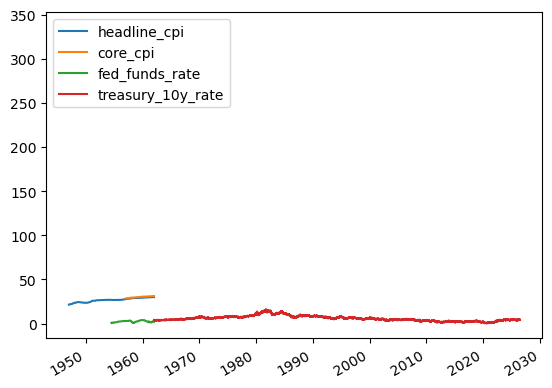

In [19]:
df.plot() ## using a plot to determine years/frequency of data collection

In [20]:
## Confirming datetime indexes to avoid hidden bugs

cpi.index = pd.to_datetime(cpi.index)
core_cpi.index = pd.to_datetime(core_cpi.index)
fed_funds.index = pd.to_datetime(fed_funds.index)
treasury.index = pd.to_datetime(treasury.index)

In [21]:
treasury.index

DatetimeIndex(['1962-01-02', '1962-01-03', '1962-01-04', '1962-01-05',
               '1962-01-08', '1962-01-09', '1962-01-10', '1962-01-11',
               '1962-01-12', '1962-01-15',
               ...
               '2026-06-12', '2026-06-15', '2026-06-16', '2026-06-17',
               '2026-06-18', '2026-06-19', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25'],
              dtype='datetime64[ns]', length=16823, freq=None)

In [22]:
## Converting daily treasury yields into monthly averages

treasury_monthly = treasury.resample('MS').mean()

treasury_monthly.tail(5)

2026-02-01    4.125789
2026-03-01    4.245909
2026-04-01    4.319091
2026-05-01    4.484000
2026-06-01    4.482222
Freq: MS, dtype: float64

In [23]:
##treasury_10y_monthly.index = treasury_monthly.index.to_period("M").to_timestamp("MS")

In [24]:
## Combining all series 

df = pd.concat([
    cpi,core_cpi,fed_funds,treasury_monthly], axis=1)

In [25]:
df.tail()

,0,1,2,3
2026-02-01,327.460,333.512,3.64,4.125789
2026-03-01,330.293,334.165,3.64,4.245909
2026-04-01,332.407,335.423,3.64,4.319091
2026-05-01,333.979,336.121,3.63,4.484000
2026-06-01,NaN,NaN,NaN,4.482222


In [26]:
## Renaming columns 

df.columns = [
    "headline_cpi_index",
    "core_cpi_index",
    "fed_funds_rate",
    "treasury_rate"
]

In [27]:
## Checking for number of missing values 

df.isna().sum()

headline_cpi_index      2
core_cpi_index        122
fed_funds_rate         91
treasury_rate         180
dtype: int64

In [28]:
## removing rows with missing values 

df_clean = df.dropna()
df_clean.index.name = 'date'

In [29]:
df_clean.info()
#df_clean.head()
df_clean.tail(10)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 772 entries, 1962-01-01 to 2026-05-01
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   headline_cpi_index  772 non-null    float64
 1   core_cpi_index      772 non-null    float64
 2   fed_funds_rate      772 non-null    float64
 3   treasury_rate       772 non-null    float64
dtypes: float64(4)
memory usage: 30.2 KB


,headline_cpi_index,core_cpi_index,fed_funds_rate,treasury_rate
date,,,,
2025-07-01,322.169,328.682,4.33,4.391818
2025-08-01,323.291,329.700,4.33,4.264762
2025-09-01,324.245,330.418,4.22,4.120476
2025-11-01,325.063,331.043,3.88,4.093889
2025-12-01,326.031,331.814,3.72,4.143182
2026-01-01,326.588,332.793,3.64,4.213500
2026-02-01,327.460,333.512,3.64,4.125789
2026-03-01,330.293,334.165,3.64,4.245909
2026-04-01,332.407,335.423,3.64,4.319091


In [30]:
df_clean.describe

<bound method NDFrame.describe of             headline_cpi_index  core_cpi_index  fed_funds_rate  treasury_rate
date                                                                         
1962-01-01              30.040          31.200            2.15       4.083182
1962-02-01              30.110          31.200            2.37       4.039444
1962-03-01              30.170          31.300            2.85       3.930455
1962-04-01              30.210          31.300            2.78       3.843000
1962-05-01              30.240          31.400            2.36       3.873636
...                        ...             ...             ...            ...
2026-01-01             326.588         332.793            3.64       4.213500
2026-02-01             327.460         333.512            3.64       4.125789
2026-03-01             330.293         334.165            3.64       4.245909
2026-04-01             332.407         335.423            3.64       4.319091
2026-05-01             333.979

Analysis Based on Objectives

1. Is Inflation pressure easing or persistent?
2. Which inflation measure better reflects ongoing cost pressure?
3. Combine inflation and interest rate indicators into a financial stress framework.
4. Analyze how interest rates respond to inflation dynamics over time to understand monetary policy reactions. 
5. Identify signals that suggest continued economic or financial stress

In [31]:
## OBJ 1: Is Inflation pressure easing or persistent?


df.columns

Index(['headline_cpi_index', 'core_cpi_index', 'fed_funds_rate',
       'treasury_rate'],
      dtype='object')

In [32]:
df_clean['headline_cpi_index'].isna().sum()

0

In [33]:
df['core_cpi_index'].isna().sum()

122

In [34]:
## Removing the year-over-year inflation rates

df_inflation = df_clean.copy()

df_inflation["headline_inflation_yoy"] = (
    df_inflation["headline_cpi_index"].pct_change(12) * 100
)

df_inflation["core_inflation_yoy"] = (
    df_inflation["core_cpi_index"].pct_change(12) * 100
)

In [35]:
## dropping rows where inflation could not be calculated

df_inflation = df_inflation.dropna()

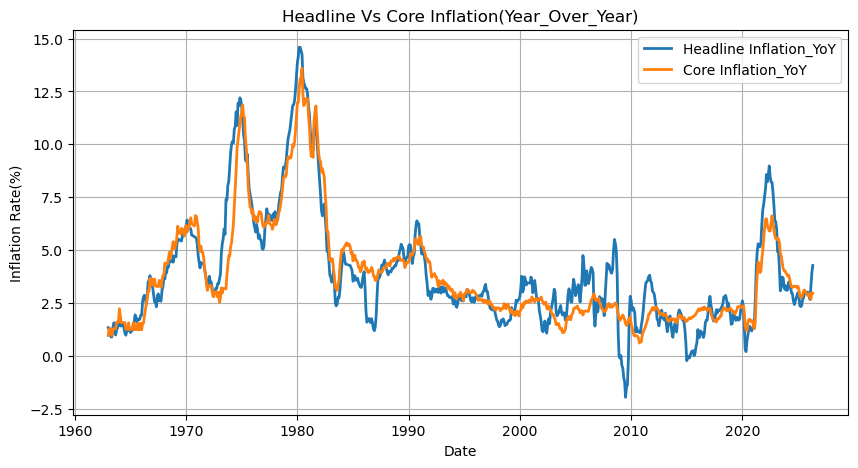

In [36]:
## Visualizing headline_inflation vs core_inflation

plt.figure(figsize=(10,5))

plt.plot(
    df_inflation.index,
    df_inflation["headline_inflation_yoy"],
    label = "Headline Inflation_YoY",
    linewidth = 2
    
    
)

plt.plot(
    df_inflation.index,
    df_inflation["core_inflation_yoy"],
    label = "Core Inflation_YoY",
    linewidth = 2
)

plt.title("Headline Vs Core Inflation(Year_Over_Year)")
plt.xlabel("Date")
plt.ylabel("Inflation Rate(%)")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
## Plottting a 6-Month rolling average 

df_inflation["headline_inflation_6m_avg"] = (
    df_inflation["headline_inflation_yoy"].rolling(6).mean()
)

df_inflation["core_inflation_6m_avg"] = (
    df_inflation["core_inflation_yoy"].rolling(6).mean()
)

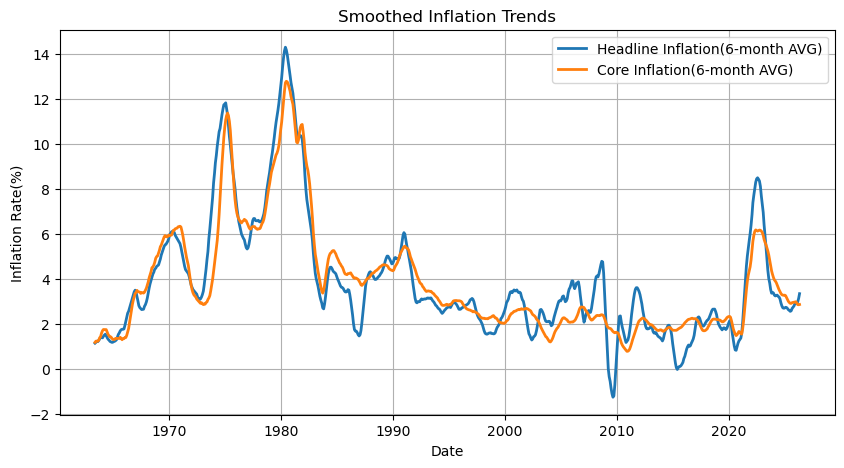

In [38]:
plt.figure(figsize=(10,5))

plt.plot(
    df_inflation.index,
    df_inflation["headline_inflation_6m_avg"],
    label = "Headline Inflation(6-month AVG)",
    linewidth = 2
    
    
)

plt.plot(
    df_inflation.index,
    df_inflation["core_inflation_6m_avg"],
    label = "Core Inflation(6-month AVG)",
    linewidth = 2
)

plt.title("Smoothed Inflation Trends")
plt.xlabel("Date")
plt.ylabel("Inflation Rate(%)")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# Obj 2: Assesing how changes in interest rates transmit into inflation trends time

"headline_cpi_index",
    "core_cpi_index",
    "fed_funds_rate",
    "treasury_rate"


In [40]:
## Previewing data to be used for analysis

#df['headline_cpi_index'].head()
df['headline_cpi_index'].describe()

count    952.000000
mean     124.931715
std       90.221330
min       21.480000
25%       32.872500
50%      109.950000
75%      201.825000
max      333.979000
Name: headline_cpi_index, dtype: float64

In [41]:
#df['core_cpi_index'].tail(5)
df['core_cpi_index'].describe()

count    832.000000
mean     143.006530
std       89.409914
min       28.500000
25%       48.350000
50%      143.150000
75%      217.046750
max      336.121000
Name: core_cpi_index, dtype: float64

In [42]:
df['fed_funds_rate'].tail(5)
df['fed_funds_rate'].describe()

count    863.000000
mean       4.598204
std        3.533383
min        0.050000
25%        1.920000
50%        4.270000
75%        6.120000
max       19.100000
Name: fed_funds_rate, dtype: float64

In [43]:
## Copying cleaned data

df_obj2 = df_clean.copy()

# Calculating month-on-month change in interest rate
df_obj2['rate_change'] = df_obj2['fed_funds_rate'].diff()



In [44]:
df_obj2[['rate_change','fed_funds_rate']].describe()

,rate_change,fed_funds_rate
count,771.000000,772.000000
mean,0.001920,4.852474
std,0.495588,3.639831
min,-6.630000,0.050000
25%,-0.060000,2.000000
50%,0.000000,4.765000
75%,0.110000,6.545000
max,3.060000,19.100000


## Preparing inflation changes 

In [45]:
df_obj2['headline_inflation_MoM'] = df_obj2['headline_cpi_index'].pct_change()*100
df_obj2['core_inflation_MoM'] =df_obj2['core_cpi_index'].pct_change()*100


In [46]:
## Previewing changes 
df_obj2[['headline_inflation_MoM','core_inflation_MoM']].isna().sum()


headline_inflation_MoM    1
core_inflation_MoM        1
dtype: int64

In [47]:
## Removing N/A values 

df_obj2 = df_obj2[['rate_change','headline_inflation_MoM','core_inflation_MoM']].dropna()

In [48]:
df_obj2.isna().sum()

rate_change               0
headline_inflation_MoM    0
core_inflation_MoM        0
dtype: int64

In [49]:
## Lag Analysis

# creating lagged inflation variables

for lag in[3,6,12]:
    df_obj2[f'headline_inflation_lag_{lag}'] = df_obj2['headline_inflation_MoM'].shift(-lag)
    df_obj2[f'core_inflation_lag_{lag}'] = df_obj2['core_inflation_MoM'].shift(-lag)

In [50]:
# Dropping N/A rows created due to lag 
df_lagged = df_obj2.dropna()
df_lagged.isna().sum()

rate_change                  0
headline_inflation_MoM       0
core_inflation_MoM           0
headline_inflation_lag_3     0
core_inflation_lag_3         0
headline_inflation_lag_6     0
core_inflation_lag_6         0
headline_inflation_lag_12    0
core_inflation_lag_12        0
dtype: int64

In [51]:
## Correlation Analysis between rate changes and future inflation 

correlations = {}

for lag in[3,6,12]:
    correlations[f'Headline CPI lag{lag}'] = df_lagged['rate_change'].corr(
            df_lagged[f'headline_inflation_lag_{lag}']

    )
    correlations[f'Core CPI lag{lag}'] = df_lagged['rate_change'].corr(
             df_lagged[f'core_inflation_lag_{lag}']

    )
    
correlations


{'Headline CPI lag3': 0.12727554346678377,
 'Core CPI lag3': 0.12469651643763374,
 'Headline CPI lag6': 0.07477246631723068,
 'Core CPI lag6': 0.03639846649002523,
 'Headline CPI lag12': 0.11296583801216895,
 'Core CPI lag12': 0.10415743734464347}

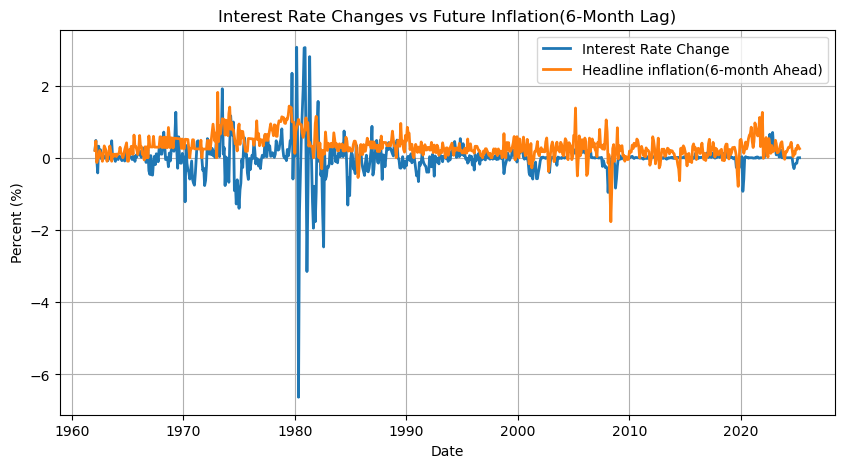

In [52]:
## Interest Rate changes vs future Inflation


plt.figure(figsize=(10,5))

plt.plot(
    df_lagged.index,
    df_lagged['rate_change'],
    label='Interest Rate Change',
    linewidth=2
)

plt.plot(
    df_lagged.index,
    df_lagged['headline_inflation_lag_6'],
    label='Headline inflation(6-month Ahead)',
    linewidth=2
)

plt.title('Interest Rate Changes vs Future Inflation(6-Month Lag)')
plt.xlabel('Date')
plt.ylabel('Percent (%)')
plt.legend()
plt.grid(True)

plt.show()

In [53]:
# OBJ 3: Combine inflation and interest rate indicators into a financial stress framework. 

In [54]:
## Copy df_cleaned 

df_obj3 = df_clean.copy()
df_obj3.head()

,headline_cpi_index,core_cpi_index,fed_funds_rate,treasury_rate
date,,,,
1962-01-01,30.04,31.2,2.15,4.083182
1962-02-01,30.11,31.2,2.37,4.039444
1962-03-01,30.17,31.3,2.85,3.930455
1962-04-01,30.21,31.3,2.78,3.843000
1962-05-01,30.24,31.4,2.36,3.873636


In [55]:
##YoY headline inflation(cost pressure)

df_obj3['headline_inflation_YoY'] = (
    df_obj3['headline_cpi_index'].pct_change(12)*100
)

## YoY core inflation
df_obj3['core_inflation_YoY'] = (
    df_obj3['core_cpi_index'].pct_change(12)*100
)

In [56]:
## keeping interest rates as levels not changes
df_obj3['interest_rate_level'] = df_obj3['fed_funds_rate']

In [57]:
## Dropping rows with incomplete stress components 

df_obj3 = df_obj3[[
    'headline_inflation_YoY','core_inflation_YoY','interest_rate_level'
]].dropna()

In [58]:
df_obj3.tail()

,headline_inflation_YoY,core_inflation_YoY,interest_rate_level
date,,,
2026-01-01,2.828680,2.949338,3.64
2026-02-01,2.664589,2.733506,3.64
2026-03-01,3.320206,2.673098,3.64
2026-04-01,3.947027,2.988425,3.64
2026-05-01,4.270033,2.957114,3.63


<Axes: xlabel='date'>

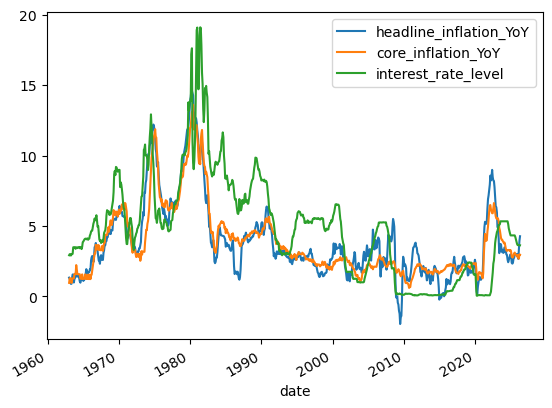

In [59]:
df_obj3.plot()

In [60]:
##Normalize components because inflation(%) and interest_rates havve different scales

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

df_obj3[['inflation_z','rate_z']] = scaler.fit_transform(
    df_obj3[['core_inflation_YoY','interest_rate_level']]
    
)

In [61]:
## Stress index(combined cost + financial stress index)

df_obj3['financial_stress_index'] = (
    df_obj3['inflation_z'] + df_obj3['rate_z']
)

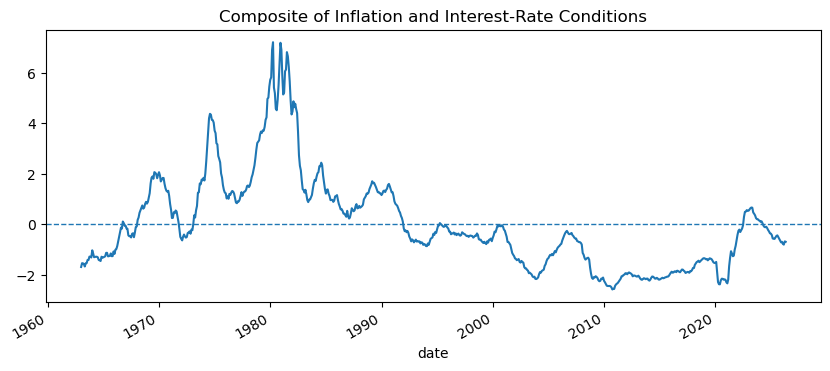

In [62]:
## Stress overtime

df_obj3['financial_stress_index'].plot(
    figsize=(10,4),
    title = "Composite of Inflation and Interest-Rate Conditions"
)

plt.axhline(0,linestyle='--',linewidth=1)
plt.show()

In [63]:
#Obj4: Analyze how interest rates respond to inflation over time.

In [64]:
df_Obj4 = df_clean.copy()

In [65]:
df_Obj4.columns

Index(['headline_cpi_index', 'core_cpi_index', 'fed_funds_rate',
       'treasury_rate'],
      dtype='object')

In [66]:
## Calculating YoY inflation(Standard policy review)
df_Obj4['headline_cpi_yoy'] = df_Obj4['headline_cpi_index'].pct_change(12) * 100
df_Obj4['core_cpi_yoy'] = df_Obj4['core_cpi_index'].pct_change(12) * 100

## Keeping fed funds at the percentage level
df_Obj4 = df_Obj4[['headline_cpi_yoy','core_cpi_yoy','fed_funds_rate']]



In [67]:
df_Obj4.describe()

,headline_cpi_yoy,core_cpi_yoy,fed_funds_rate
count,760.000000,760.000000,772.000000
mean,3.862000,3.820426,4.852474
std,2.791041,2.484535,3.639831
min,-1.958761,0.602718,0.050000
25%,2.033159,2.120171,2.000000
50%,3.082789,2.995543,4.765000
75%,4.714815,4.786855,6.545000
max,14.592275,13.604488,19.100000


In [68]:
df_Obj4.isna().sum()

headline_cpi_yoy    12
core_cpi_yoy        12
fed_funds_rate       0
dtype: int64

In [69]:
# dropping rows where calculations are not available
df_Obj4 = df_Obj4.dropna()

In [70]:
df_Obj4.isna().sum()

headline_cpi_yoy    0
core_cpi_yoy        0
fed_funds_rate      0
dtype: int64

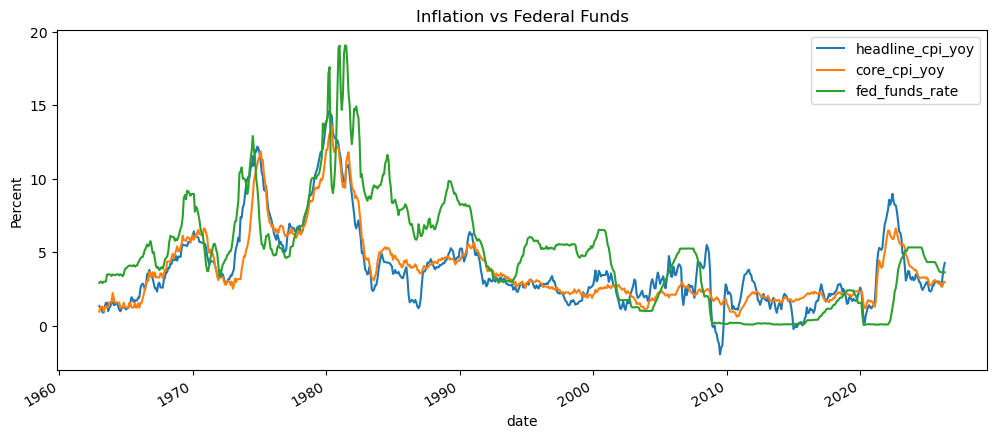

In [71]:
## Visual Comparison 

df_Obj4.plot(
    figsize=(12,5),
    title='Inflation vs Federal Funds'
)

plt.ylabel('Percent')
plt.show()

In [72]:
## Lag Analysis(does policy react with delay)

#creating lag inflation variables(3,6,12 months)

for lag in [3,6,12]:
    df_Obj4[f'headline_lag{lag}'] = df_Obj4['headline_cpi_yoy'].shift(lag)
    df_Obj4[f'core_lag{lag}'] = df_Obj4['core_cpi_yoy'].shift(lag)

## df_lag = df_Obj4.isna().sum()

In [73]:
df_lag = df_Obj4.dropna()

In [74]:
df_lag.columns

Index(['headline_cpi_yoy', 'core_cpi_yoy', 'fed_funds_rate', 'headline_lag3',
       'core_lag3', 'headline_lag6', 'core_lag6', 'headline_lag12',
       'core_lag12'],
      dtype='object')

In [75]:
## Relationship check

correlation_results = df_lag[
    ['fed_funds_rate',
    'headline_lag3','core_lag3', 'headline_lag6', 'core_lag6', 'headline_lag12',
       'core_lag12']
].corr()

correlation_results['fed_funds_rate'].sort_values(ascending=False)


fed_funds_rate    1.000000
core_lag3         0.733177
core_lag6         0.728578
core_lag12        0.704492
headline_lag6     0.697543
headline_lag3     0.696540
headline_lag12    0.675059
Name: fed_funds_rate, dtype: float64

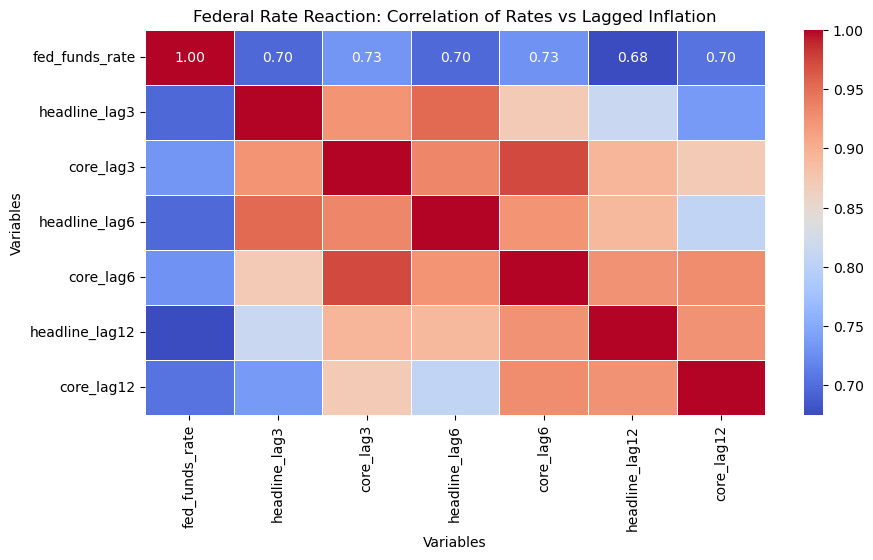

In [76]:


plt.figure(figsize=(10,5))

sns. heatmap(
    correlation_results,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidth=0.5
    
)

plt.title('Federal Rate Reaction: Correlation of Rates vs Lagged Inflation')
plt.ylabel('Variables')
plt.xlabel('Variables')

plt.show()